# Homework 2: Convolutional Neural Networks on CIFAR-10

**Goal:** Build a CNN that reaches **at least 75% test accuracy** on CIFAR-10.

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import time

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

torch.manual_seed(42)
np.random.seed(42)


Using device: cuda:0


In [18]:
torchvision.datasets.CIFAR10.url = "https://data.brainchip.com/dataset-mirror/cifar10/cifar-10-python.tar.gz"

# Standard CIFAR-10 normalization stats
stats = ((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))

# 1. Baseline transforms (no augmentation)
transform_baseline = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(*stats),
])

# 2. Augmented transforms used for the augmented experiment
transform_augmented = transforms.Compose([
    transforms.RandomCrop(32, padding=4),       # padding preserves size after crop
    transforms.RandomHorizontalFlip(),          # 50% chance to flip
    transforms.RandomRotation(10),              # slight rotation
    transforms.ToTensor(),
    transforms.Normalize(*stats),
])

# Test transforms (never augmented)
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(*stats),
])

batch_size = 128

# Baseline train loader
trainset_base = torchvision.datasets.CIFAR10(root='./data', train=True,
                                               download=True, transform=transform_baseline)
trainloader_base = torch.utils.data.DataLoader(trainset_base, batch_size=batch_size,
                                                 shuffle=True, num_workers=2)

# Augmented train loader
trainset_aug = torchvision.datasets.CIFAR10(root='./data', train=True,
                                             download=True, transform=transform_augmented)
trainloader_aug = torch.utils.data.DataLoader(trainset_aug, batch_size=batch_size,
                                               shuffle=True, num_workers=2)

# Test loader
testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                        download=True, transform=transform_test)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                          shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
print(f"Train samples (base): {len(trainset_base)} | Train samples (aug): {len(trainset_aug)} | Test samples: {len(testset)}")


Train samples: 50000 | Test samples: 10000


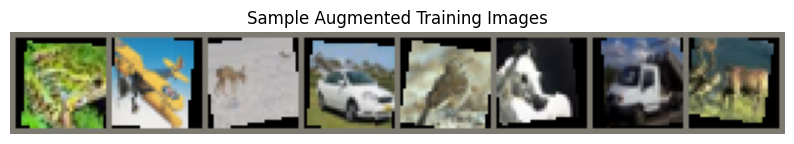

In [19]:
mean = torch.tensor(stats[0]).view(3, 1, 1)
std = torch.tensor(stats[1]).view(3, 1, 1)

def imshow(img, title=None):
    img = img * std + mean  # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    if title:
        plt.title(title)
    plt.axis('off')

dataiter = iter(trainloader_aug)
images, labels = next(dataiter)

plt.figure(figsize=(10, 4))
imshow(torchvision.utils.make_grid(images[:8]), title="Sample Augmented Training Images")
plt.show()


In [20]:
class DeepCNN(nn.Module):
    def __init__(self):
        super(DeepCNN, self).__init__()

        # Block 1: 3 -> 64
        self.conv1a = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.bn1a = nn.BatchNorm2d(64)
        self.conv1b = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn1b = nn.BatchNorm2d(64)

        # Block 2: 64 -> 128
        self.conv2a = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn2a = nn.BatchNorm2d(128)
        self.conv2b = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn2b = nn.BatchNorm2d(128)

        # Block 3: 128 -> 256
        self.conv3a = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn3a = nn.BatchNorm2d(256)
        self.conv3b = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.bn3b = nn.BatchNorm2d(256)

        self.max_pool = nn.MaxPool2d(kernel_size=2)
        self.relu = nn.ReLU()

        self.dropout1 = nn.Dropout(0.2)
        self.dropout2 = nn.Dropout(0.3)
        self.dropout3 = nn.Dropout(0.4)
        self.dropout_fc = nn.Dropout(0.5)

        self.flatten = nn.Flatten()
        self.linear1 = nn.Linear(4 * 4 * 256, 512)
        self.linear2 = nn.Linear(512, 10)

    def forward(self, x):
        # Block 1: 32x32 -> 16x16
        x = self.conv1a(x)
        x = self.bn1a(x)
        x = self.relu(x)
        x = self.conv1b(x)
        x = self.bn1b(x)
        x = self.relu(x)
        x = self.max_pool(x)
        x = self.dropout1(x)

        # Block 2: 16x16 -> 8x8
        x = self.conv2a(x)
        x = self.bn2a(x)
        x = self.relu(x)
        x = self.conv2b(x)
        x = self.bn2b(x)
        x = self.relu(x)
        x = self.max_pool(x)
        x = self.dropout2(x)

        # Block 3: 8x8 -> 4x4
        x = self.conv3a(x)
        x = self.bn3a(x)
        x = self.relu(x)
        x = self.conv3b(x)
        x = self.bn3b(x)
        x = self.relu(x)
        x = self.max_pool(x)
        x = self.dropout3(x)

        x = self.flatten(x)
        x = self.linear1(x)
        x = self.relu(x)
        x = self.dropout_fc(x)
        x = self.linear2(x)
        return x

model = DeepCNN().to(device)
print(model)

DeepCNN(
  (conv1a): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1a): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv1b): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1b): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2a): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2a): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2b): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2b): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3a): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3a): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3b): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3b): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True,

In [24]:
def train_model(model, train_loader, test_loader, epochs=30, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    train_losses = []
    test_accs = []
    best_acc = 0.0

    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        scheduler.step()

        # Evaluate on test set
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        epoch_acc = 100 * correct / total
        avg_loss = running_loss / len(train_loader)

        train_losses.append(avg_loss)
        test_accs.append(epoch_acc)
        best_acc = max(best_acc, epoch_acc)

        print(f"Epoch [{epoch+1}/{epochs}] Loss: {avg_loss:.4f} | Test Acc: {epoch_acc:.2f}% | LR: {scheduler.get_last_lr()[0]:.5f}")

    print(f"\nTraining finished in {time.time() - start_time:.2f}s")
    print(f"Best test accuracy: {best_acc:.2f}%")
    return train_losses, test_accs, best_acc


In [26]:
print("--- EXPERIMENT 1: Baseline (No Augmentation) ---")
model_base = DeepCNN().to(device)
loss_base, acc_base = train_model(model_base, trainloader_base, testloader, epochs=30)

print("\n--- EXPERIMENT 2: With Data Augmentation ---")
model_aug = DeepCNN().to(device)
loss_aug, acc_aug = train_model(model_aug, trainloader_aug, testloader, epochs=30)

--- EXPERIMENT 1: Baseline (No Augmentation) ---


NameError: name 'trainloader_base' is not defined

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(loss_base, label='Baseline (No Aug)', linestyle='--')
plt.plot(loss_aug, label='With Augmentation', linewidth=2)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(acc_base, label='Baseline (No Aug)', linestyle='--')
plt.plot(acc_aug, label='With Augmentation', linewidth=2)
plt.axhline(y=75, color='red', linestyle='--', label='75% target')
plt.title('Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
model_aug.eval()
correct = 0
total = 0
class_correct = [0] * 10
class_total = [0] * 10

with torch.no_grad():
    for inputs, labels in testloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_aug(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        for label, pred in zip(labels, predicted):
            class_correct[label.item()] += int(label == pred)
            class_total[label.item()] += 1

final_acc = 100 * correct / total
print(f"Final Test Accuracy: {final_acc:.2f}%")
print(f"Best Test Accuracy during training (augmented model): {max(acc_aug):.2f}%")
print("\nPer-class accuracy:")
for i, c in enumerate(classes):
    print(f"  {c:>6}: {100 * class_correct[i] / class_total[i]:.2f}%")

assert final_acc >= 75 or max(acc_aug) >= 75, "Target of 75% accuracy not reached — consider training for more epochs."


In [ ]:
import torch.nn.functional as F

model_aug.eval()
mistakes = []  # list of (confidence, image_tensor, predicted_label, true_label)

with torch.no_grad():
    for images, labels in testloader:
        images_dev, labels_dev = images.to(device), labels.to(device)

        outputs = model_aug(images_dev)
        probs = F.softmax(outputs, dim=1)
        confidences, preds = torch.max(probs, dim=1)

        wrong_mask = preds != labels_dev
        wrong_idx = wrong_mask.nonzero(as_tuple=True)[0]

        for idx in wrong_idx:
            mistakes.append((
                confidences[idx].item(),
                images[idx].cpu(),          # keep the original (un-normalized-in-place) CPU tensor
                preds[idx].item(),
                labels[idx].item(),
            ))

# Sort by confidence, highest (most confidently wrong) first
mistakes.sort(key=lambda x: x[0], reverse=True)

print(f"Total mistakes on test set: {len(mistakes)} out of {len(testset)} images")

# Plot the top 5 most confidently incorrect predictions
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    conf, img, pred, true = mistakes[i]
    img = img*std + mean
    img = img.clamp(0, 1)
    npimg = img.numpy()
    axes[i].imshow(np.transpose(npimg, (1, 2, 0)))
    axes[i].set_title(f"Pred: {classes[pred]} ({conf:.2f})\nTrue: {classes[true]}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()
